In [1]:
import math 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
np.random.seed(42)

In [2]:
class value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0 # Gradient
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"value(data = {self.data:1f})"

    def __add__(self, other):
        out = value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = value(self.data * other.data, (self, other), '*')
        return out

In [3]:
a = value(3, label = 'a')
b = value(7, label = 'b')

In [4]:
c = a + b; c.label = 'c'
print(c)

value(data = 10.000000)


In [5]:
d = a * b + c 
d

value(data = 31.000000)

In [6]:
d._prev

{value(data = 10.000000), value(data = 21.000000)}

In [7]:
d._op

'+'

In [8]:
from graphviz import Digraph
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [9]:
c = a * b; c.label = 'c'

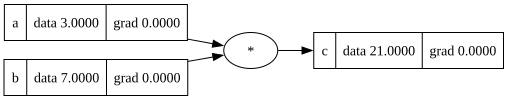

In [10]:
draw_dot(c)

c = a * b

dc / da = b  (b becomes constant)

dc / db = a  (a becomes constant)

In [11]:
def lol():
    h = 0.0001
    
    a = value(2)
    b = value(3)
    c1 = a * b
    c1 = c1.data
    
    a = value(2)
    # a.data += h
    b = value(3)
    b.data += h
    c2 = a * b
    c2 = c2.data
    
    print((c2 - c1) / h)

lol()
    
    

2.0000000000042206


In [20]:
a = value(5); a.label = 'a'
b = value(9); b.label = 'b'

c = a * b; c.label = 'c'
d = value(10); d.label = 'd'
e = d + c; e.label = 'e'

f = value(3); f.label = 'f'
g = f * e; g.label = 'g'

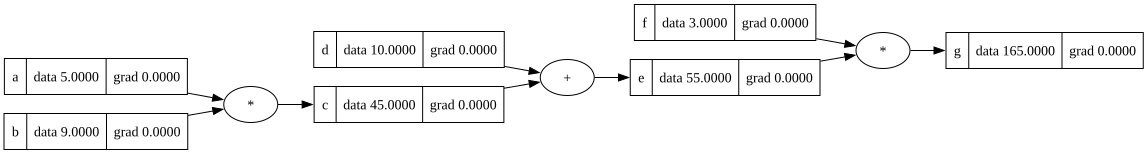

In [21]:
draw_dot(g)

In [24]:
# dg/ dg = 1 
g.grad = 1

f.grad = e.data
e.grad = f.data

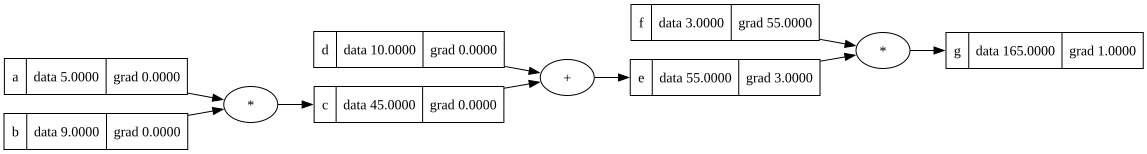

In [25]:
draw_dot(g)

e = d + c  

de / dd = 1    
de/dc = 1  

dg / de = 3  
de/dd = 1  
dg / dd = (dg / de) * (de / dd) = 3 * 1 = 3  
dg / dc = (dg / de) * (de / dc) = 3 * 1 = 3  


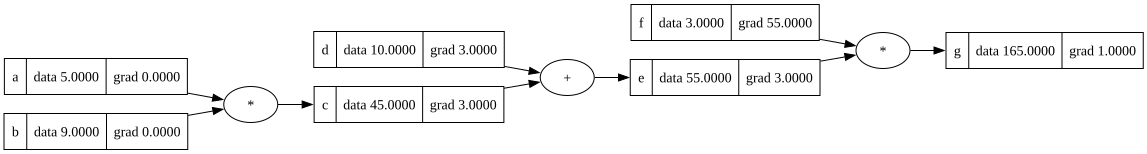

In [26]:
d.grad = e.grad
c.grad = e.grad
draw_dot(g)



dg / da = (dg / de) * (de / dc) * (dc / da)  
dg / db = (dg / de) * (de / dc) * (dc / db)  

dc / da  = 9  
dc / db = 5  

dg / da = 3 * 3 * 9 = 81  
dg / db = 3 * 3 * 5 = 45  

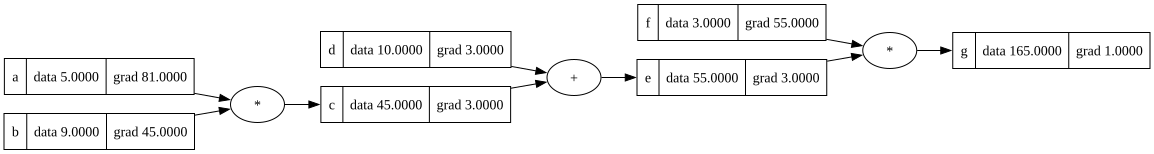

In [28]:
a.grad = 81 
b.grad = 45
draw_dot(g)